In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import os

In [2]:
from src.loader import load_all_samples
from src.filter import filter_data
from src.filter import normalize_and_select_genes
from src.clustering import run_pca
from src.clustering import run_clustering

Is index unique? True
Number of mitochondrial genes detected: 13

QC metrics added to adata.obs:
['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']

QC Statistics:


,total_counts,n_genes_by_counts,pct_counts_mt
count,34078.000000,34078.000000,34078.000000
mean,630.604492,2290.729415,2.499186
std,61.527061,1018.252556,0.938393
min,119.023888,203.000000,0.000000
25%,592.297119,1672.000000,2.106632
50%,633.059692,2122.000000,2.416822
75%,674.417587,2642.000000,2.746958
max,802.334778,10984.000000,40.870228


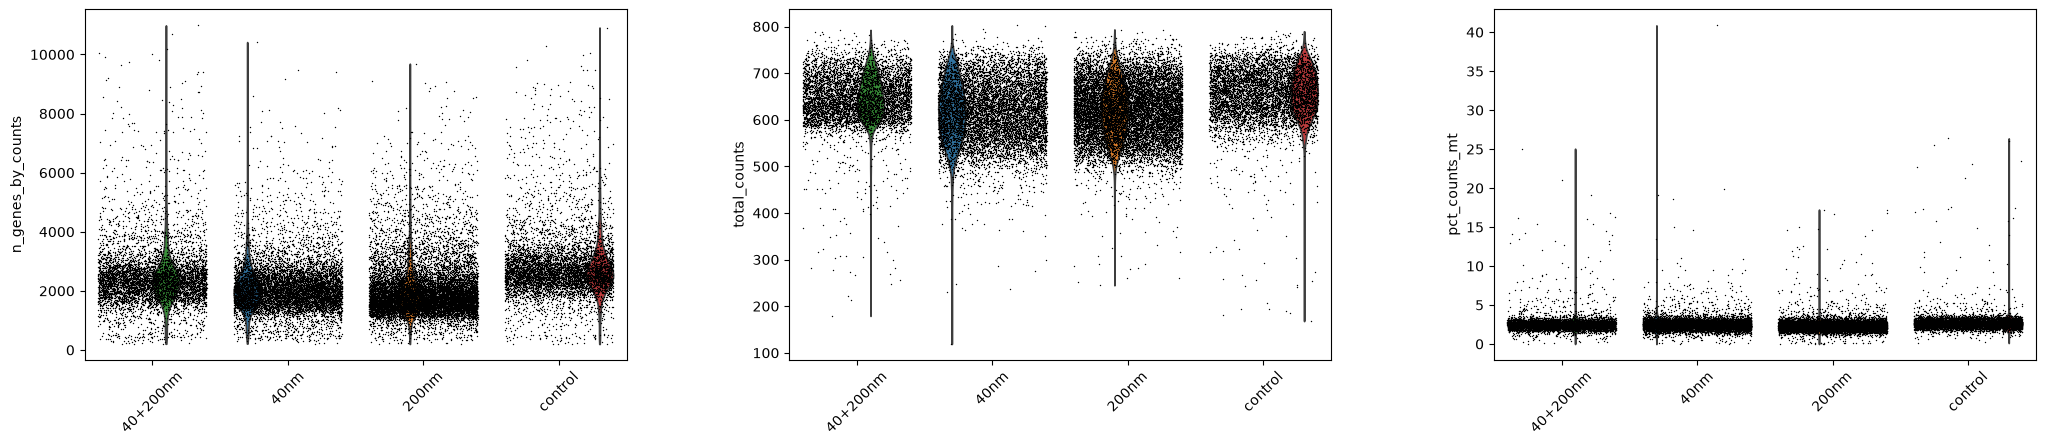

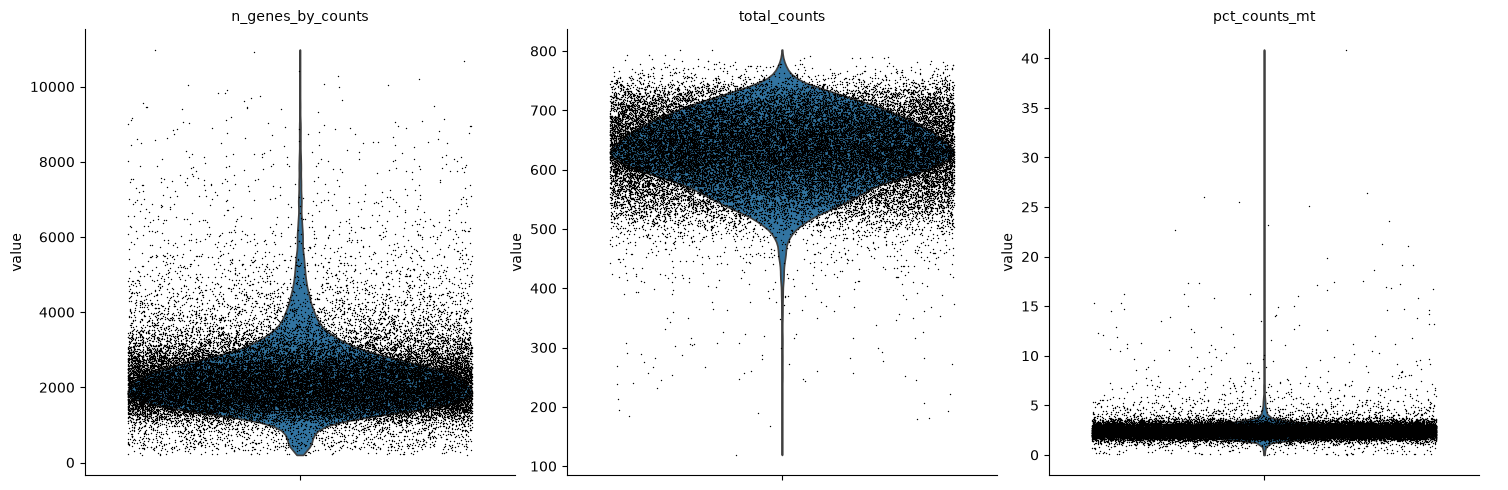

In [3]:
# Read H5AD file
adata = load_all_samples()

print(f"Is index unique? {adata.obs.index.is_unique}")

adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(f"Number of mitochondrial genes detected: {adata.var['mt'].sum()}")
print(f"\nQC metrics added to adata.obs:")
print([col for col in adata.obs.columns if col.startswith(('total_counts', 'n_genes', 'pct_counts'))])
# Display summary statistics
print("\nQC Statistics:")
qc_stats = adata.obs[['total_counts', 'n_genes_by_counts', 'pct_counts_mt']].describe()
display(qc_stats)

# Calculate QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True, show=False, groupby='sample_id', rotation=45)
plt.savefig('results/qc_scatter_feature.png')

# Calculate QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True, show=False)
plt.savefig('results/qc_scatter.png')

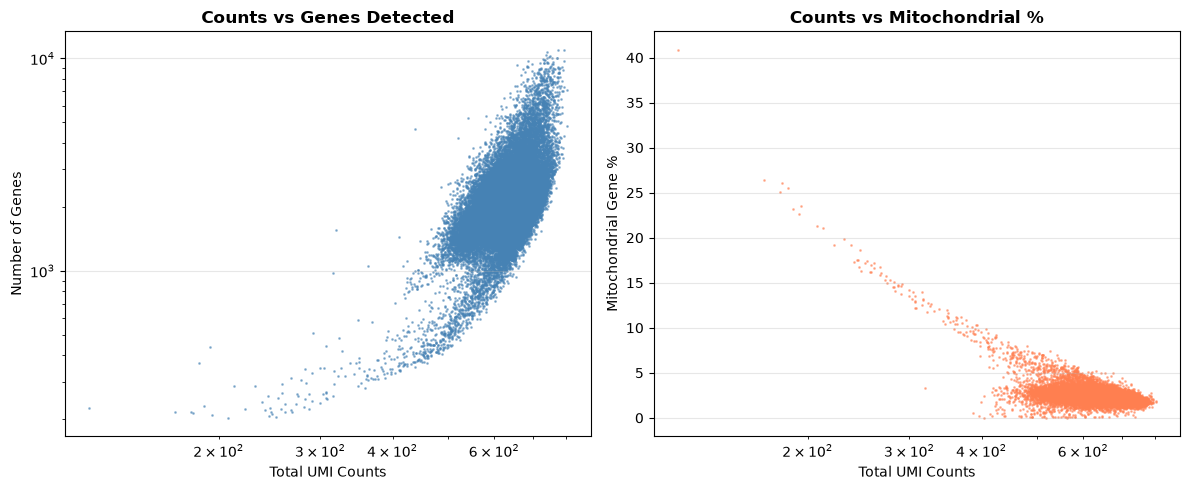


✓ QC scatter plots generated


In [4]:
# Scatter plots to identify outliers and correlations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total counts vs genes detected
axes[0].scatter(
    adata.obs['total_counts'],
    adata.obs['n_genes_by_counts'],
    alpha=0.5,
    s=1,
    c='steelblue'
)
axes[0].set_xlabel('Total UMI Counts', fontsize=10)
axes[0].set_ylabel('Number of Genes', fontsize=10)
axes[0].set_title('Counts vs Genes Detected', fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Total counts vs mitochondrial percentage
axes[1].scatter(
    adata.obs['total_counts'],
    adata.obs['pct_counts_mt'],
    alpha=0.5,
    s=1,
    c='coral'
)
axes[1].set_xlabel('Total UMI Counts', fontsize=10)
axes[1].set_ylabel('Mitochondrial Gene %', fontsize=10)
axes[1].set_title('Counts vs Mitochondrial %', fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ QC scatter plots generated")

In [5]:
# Calculate how many cells each gene appears in
gene_occurrence = (adata.X > 0).sum(axis=0)
if hasattr(gene_occurrence, 'A1'): gene_occurrence = gene_occurrence.A1

import pandas as pd
# Create a frequency table for the first 10 values
counts = pd.Series(gene_occurrence).value_counts().sort_index().head(10)

print("Number of cells | Number of genes found in exactly that many cells")
print("----------------|-----------------------------------------------")
print(counts)

Number of cells | Number of genes found in exactly that many cells
----------------|-----------------------------------------------
3     754
4     321
5     171
6     290
7     261
8     195
9     203
10    180
11    159
12    160
Name: count, dtype: int64


In [6]:
adata = filter_data(adata, 500, 4000, 5)

Stats BEFORE filtering: 34078 cells, 24380 genes
Stats AFTER filtering: 31767 cells, 24380 genes


In [7]:
adata = normalize_and_select_genes(adata)

Step 1: Saving raw counts...
Step 2: Normalizing total counts...
Step 3: Log-transforming...
Step 4: Identifying Highly Variable Genes (HVGs)...
Number of HVGs after excluding MT/Ribo: 1991


/usr/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/jovan/Documents/gi/gi-2026/src/clustering.py:12: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(


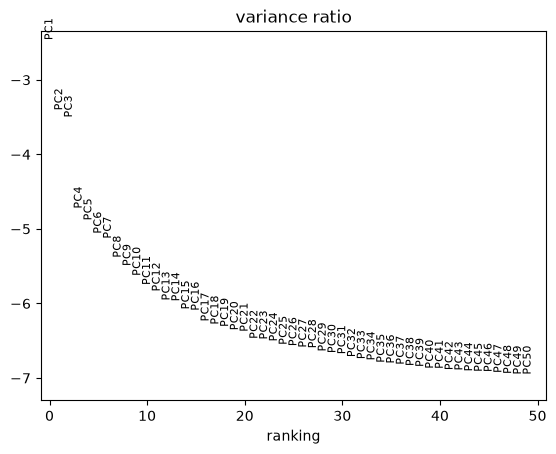

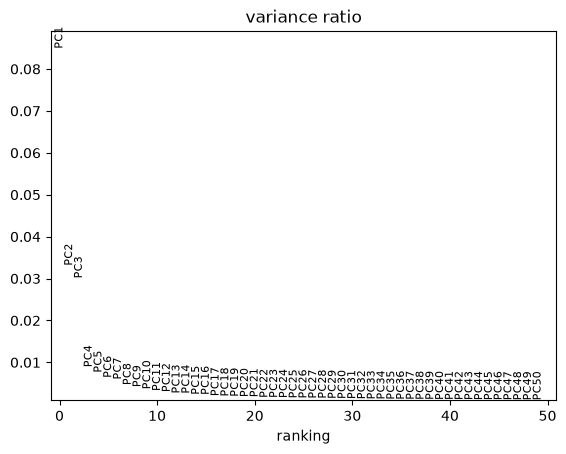

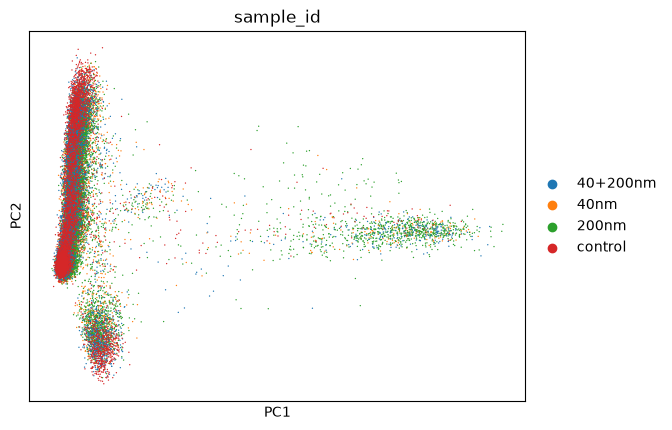

In [8]:
adata = run_pca(adata)

In [9]:
# Calculate variance explained by each PC
variance_ratio = adata.uns['pca']['variance_ratio']
print(f"\nVariance explained by first 10 PCs: {100 * variance_ratio[:10].sum():.2f}%")
print(f"Variance explained by first 30 PCs: {100 * variance_ratio[:30].sum():.2f}%")


Variance explained by first 10 PCs: 18.89%
Variance explained by first 30 PCs: 22.64%


/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jovan/Documents/gi/gi-2026/src/clustering.py:46: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


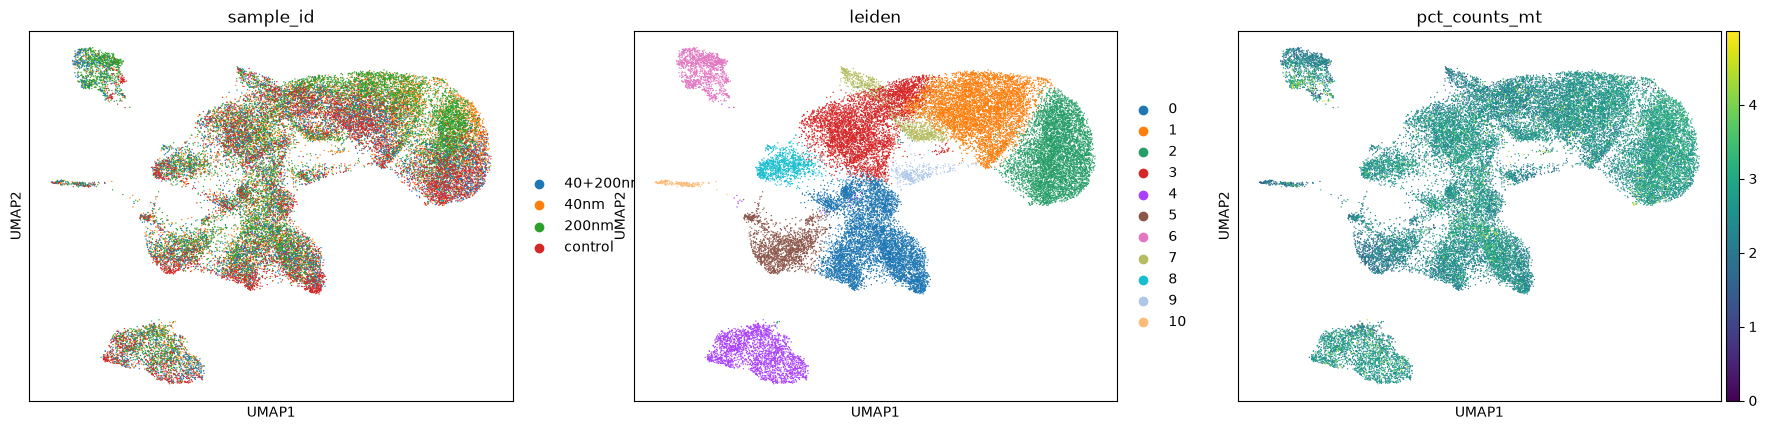

In [10]:
adata = run_clustering(adata)

n_clusters = adata.obs['leiden'].nunique()

In [11]:
# Find marker genes for Leiden clusters
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',  # Group by Leiden clusters
    method='wilcoxon',  # Statistical test method - does not assume normal distribution, compares medians rather than mean
    key_added='rank_genes_leiden',
    use_raw=False,
    layer='norm_log'
)

print("✓ Marker genes computed for Leiden clusters")
print(f"  - Method: wilcoxon")
print(f"  - Clusters analyzed: {n_clusters}")

✓ Marker genes computed for Leiden clusters
  - Method: wilcoxon
  - Clusters analyzed: 11


In [12]:
# Overview plot of top marker genes
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False,
    key='rank_genes_leiden',
    show=False
)

plt.savefig('results/marker_genes.png')
plt.close()

print("\n✓ Marker genes overview plot generated")


✓ Marker genes overview plot generated


In [13]:
# Extract marker genes as a DataFrame
marker_genes_df = sc.get.rank_genes_groups_df(
    adata,
    group=None,  # Get markers for all groups
    key='rank_genes_leiden'
)

print("\nTop 5 marker genes per cluster:")
print("="*80)

for cluster in sorted(adata.obs['leiden'].unique()):
    cluster_markers = marker_genes_df[
        marker_genes_df['group'] == cluster
    ].head(5)

    print(f"\nCluster {cluster}:")
    for idx, row in cluster_markers.iterrows():
        print(f"  {row['names']:15s} | score: {row['scores']:6.2f} | "
              f"logFC: {row['logfoldchanges']:6.2f} | p-val: {row['pvals']:.2e}")


Top 5 marker genes per cluster:

Cluster 0:
  CCL5            | score: 108.91 | logFC:   4.69 | p-val: 0.00e+00
  AOAH            | score:  93.28 | logFC:   3.73 | p-val: 0.00e+00
  ZEB2            | score:  86.62 | logFC:   3.54 | p-val: 0.00e+00
  TGFBR3          | score:  79.04 | logFC:   3.41 | p-val: 0.00e+00
  C1orf21         | score:  78.89 | logFC:   4.03 | p-val: 0.00e+00

Cluster 1:
  EEF1B2          | score:  67.77 | logFC:   1.18 | p-val: 0.00e+00
  LTB             | score:  65.09 | logFC:   1.80 | p-val: 0.00e+00
  ANK3            | score:  60.07 | logFC:   2.18 | p-val: 0.00e+00
  CCR7            | score:  59.95 | logFC:   1.78 | p-val: 0.00e+00
  FHIT            | score:  59.27 | logFC:   2.95 | p-val: 0.00e+00

Cluster 10:
  ATP10D          | score:  23.39 | logFC:   7.37 | p-val: 5.71e-121
  SIPA1L1         | score:  22.78 | logFC:   4.25 | p-val: 6.86e-115
  GAB2            | score:  22.68 | logFC:   5.05 | p-val: 7.73e-114
  CHN2            | score:  21.50 | logFC: 

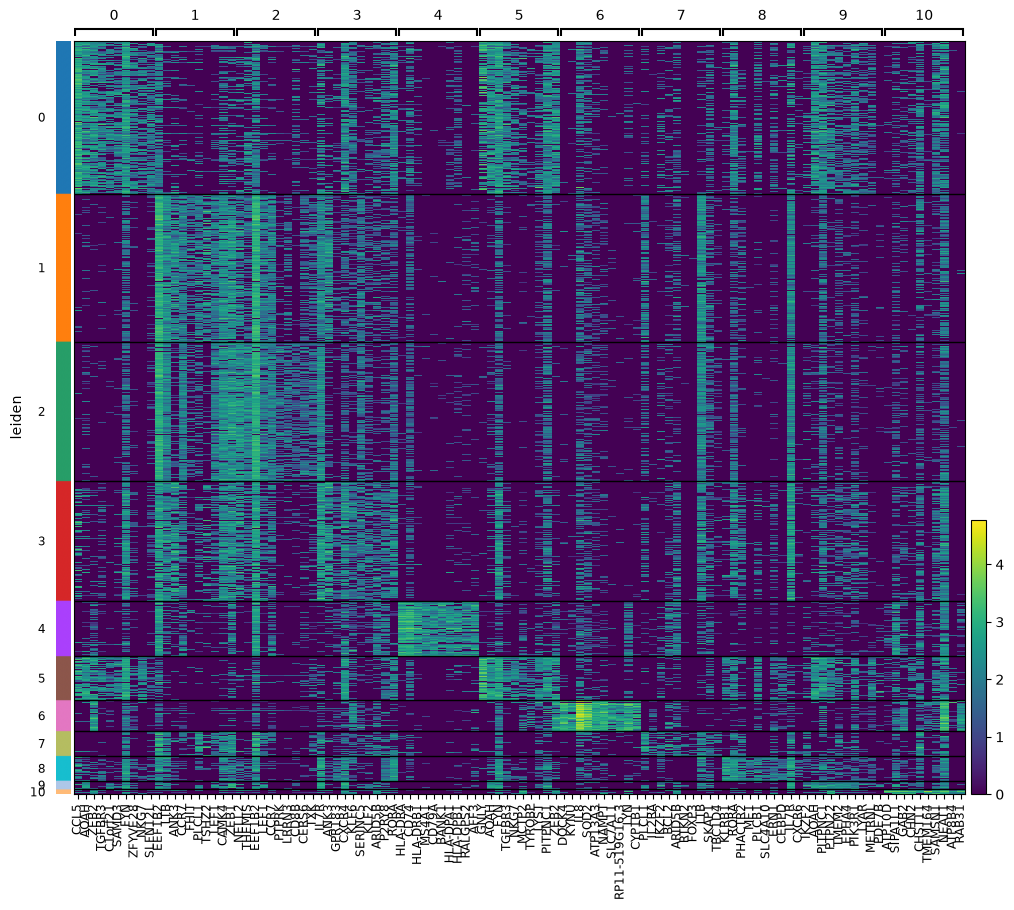


✓ Marker genes heatmap generated


In [14]:
# Heatmap of top marker genes
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=10,
    key='rank_genes_leiden',
    groupby='leiden',
    show_gene_labels=True,
    figsize=(12, 10),
    dendrogram=False,
    show=True
)

print("\n✓ Marker genes heatmap generated")

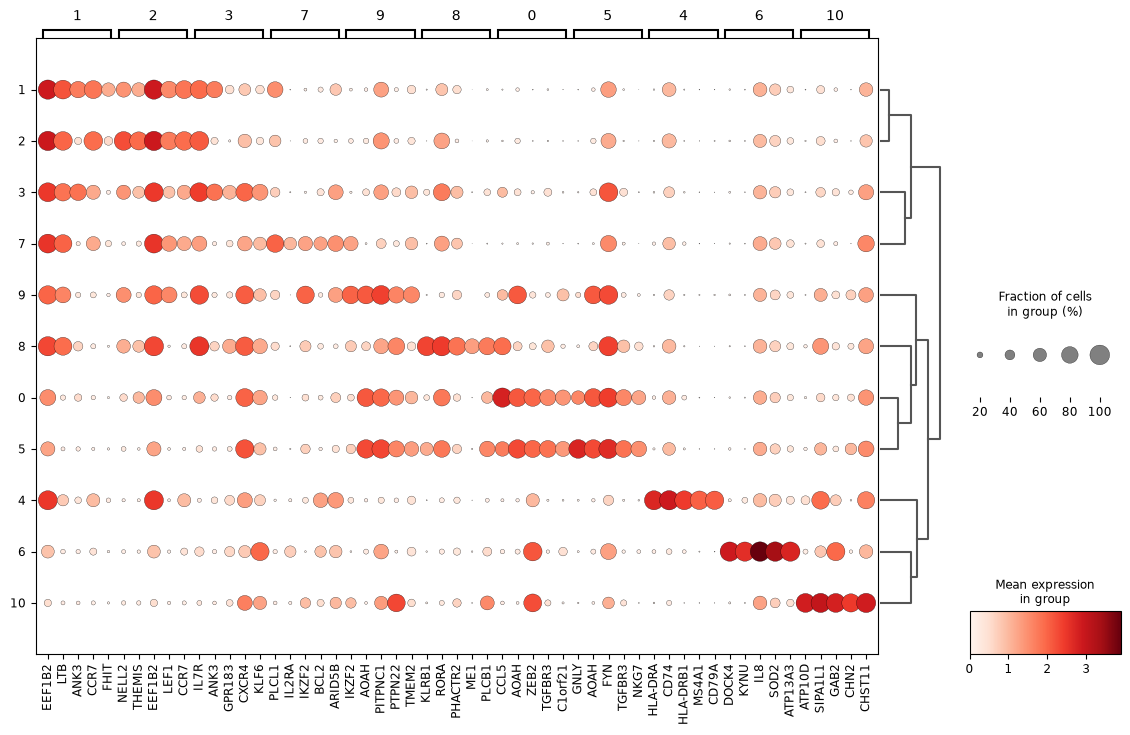


✓ Marker genes dot plot generated


In [15]:
# Dot plot of top marker genes
sc.tl.dendrogram(adata, groupby='leiden')
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    key='rank_genes_leiden',
    groupby='leiden',
    figsize=(14, 8),
    show=True
)

print("\n✓ Marker genes dot plot generated")

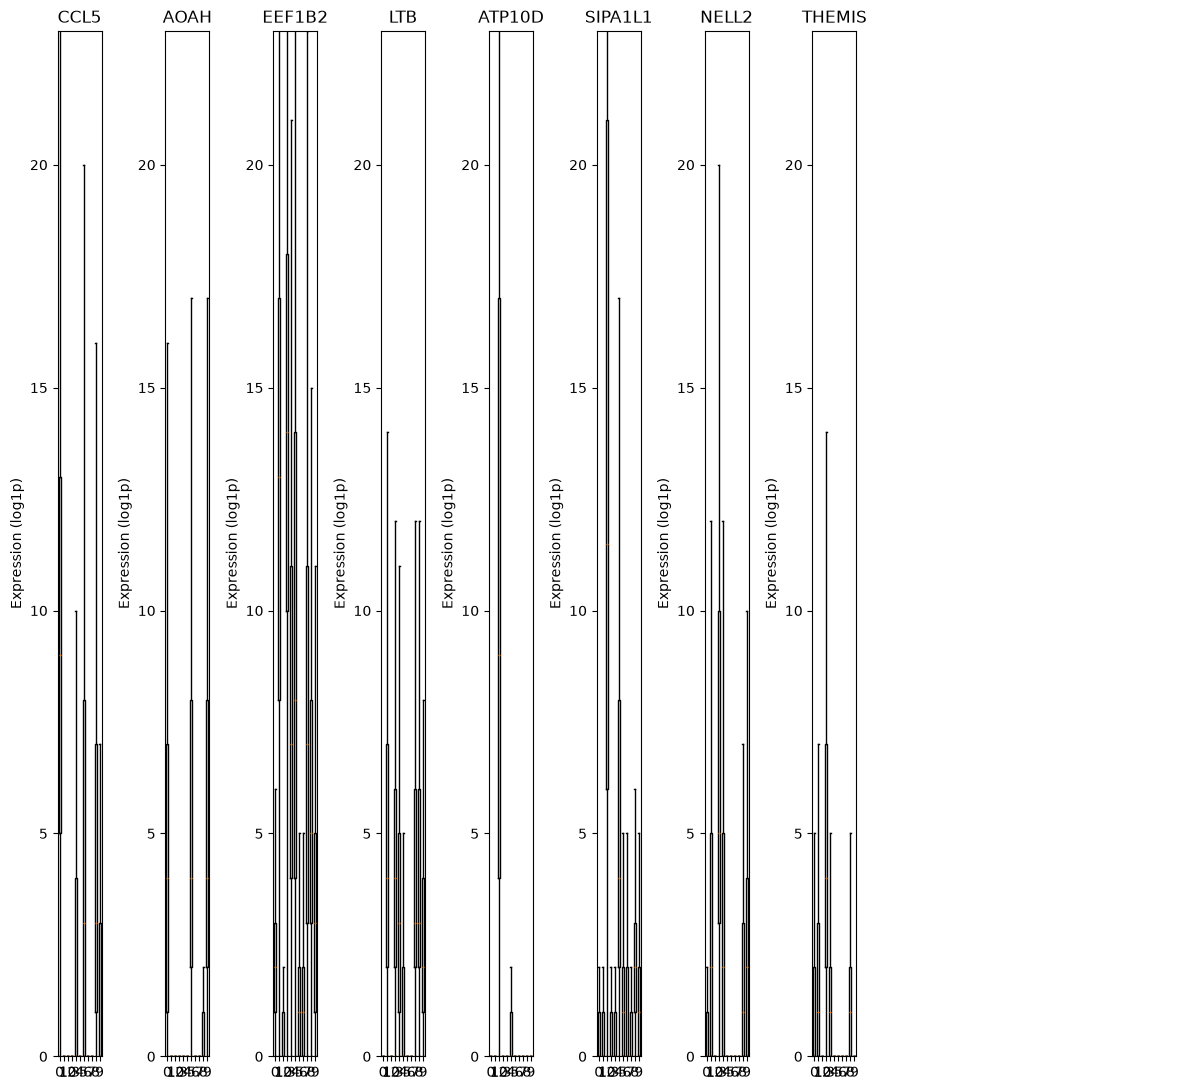


✓ Marker genes plots generated


In [ ]:
# Get top 3 marker genes for all clusters for violin plots
top_genes = []
for cluster in sorted(adata.obs['leiden'].unique()):  # All clusters
    cluster_markers = marker_genes_df[
        marker_genes_df['group'] == cluster
    ].head(2)
    top_genes.extend(cluster_markers['names'].tolist())

# Remove duplicates while preserving order
top_genes = list(dict.fromkeys(top_genes))[:8]  # Limit to 8 genes

# Violin plot
if len(top_genes) > 0:
    genes = top_genes
    clusters = sorted(adata.obs['leiden'].unique())

    # Choose expression source:
    # - adata.X        → usually log1p-normalized
    # - adata.layers[normlog]    → if log1p stored
    # - adata.layers[] → e.g. 'counts'
    gene_idx = [adata.var_names.get_loc(g) for g in genes]
    X = adata.layers["counts"][:, gene_idx]

    # Convert sparse to dense if needed
    if hasattr(X, "toarray"):
        X = X.toarray()

    # Build expression DataFrame
    expr = pd.DataFrame(
        X,
        columns=genes,
        index=adata.obs['leiden']
    )

    # -----------------------------
    # Plot: boxplots in a grid
    # -----------------------------
    n_genes = len(genes)
    n_cols = len(adata.obs['leiden'].unique())
    n_rows = int(np.ceil(n_genes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12 * n_cols, n_rows))
    axes = axes.flatten()

    # Optional: consistent y-axis across genes
    ymax = np.percentile(expr.values, 99)

    for ax, gene in zip(axes, genes):
        data = [expr.loc[cluster, gene].values for cluster in clusters]

        ax.boxplot(
            data,
            showfliers=False
        )
        ax.set_title(gene)
        ax.set_xticks(range(1, len(clusters) + 1))
        ax.set_xticklabels(clusters, rotation=0)
        ax.set_ylabel("Expression (log1p)")
        ax.set_ylim(0, ymax)

    # Hide unused panels
    for ax in axes[len(genes):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print("\n✓ Marker genes plots generated")
else:
    print("\n⚠ No marker genes found for violin plot")